In [ ]:
import os
import numpy as np
from sklearn.utils import class_weight

DATASET_PATH = 'master_dataset/dataset_kematangan_buah/train'

# 1. Audit Jumlah Data Per Kelas
folders = [f for f in os.listdir(DATASET_PATH) if not f.startswith('.')]
class_counts = {}

for folder in folders:
    count = len(os.listdir(os.path.join(DATASET_PATH, folder)))
    class_counts[folder] = count

print("=== HASIL AUDIT DATASET KEMATANGAN ===")
for cls, count in class_counts.items():
    print(f"Kelas {cls}: {count} gambar")

# 2. Hitung Class Weight Otomatis
labels = sorted(class_counts.keys())
counts = [class_counts[label] for label in labels]

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=np.repeat(labels, counts)
)

class_weight_dict = {i: weight for i, weight in enumerate(weights)}

print("\n=== BOBOT KELAS (CLASS WEIGHT) UNTUK TRAINING ===")
for i, label in enumerate(labels):
    print(f"Index {i} ({label}): {class_weight_dict[i]:.4f}")

=== HASIL AUDIT DATASET KEMATANGAN ===
Kelas unripe: 878 gambar
Kelas overripe: 505 gambar
Kelas ripe: 961 gambar

=== BOBOT KELAS (CLASS WEIGHT) UNTUK TRAINING ===
Index 0 (overripe): 1.5472
Index 1 (ripe): 0.8130
Index 2 (unripe): 0.8899


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Konfigurasi Path & Hyperparameters
BASE_DIR = 'master_dataset/dataset_kematangan_buah'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. Augmentasi Khusus Kematangan (Color-Safe)
# Fokus pada simulasi cahaya (brightness) dan detail (zoom)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2], # Simulasi cahaya pasar/kebun
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Test & Val tidak boleh diaugmentasi, hanya rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Flow From Directory
train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'test'), # Menggunakan split test sebagai validasi sementara
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(f"\n[INFO] Indeks Kelas: {train_generator.class_indices}")

Found 2341 images belonging to 3 classes.
Found 300 images belonging to 3 classes.

[INFO] Indeks Kelas: {'overripe': 0, 'ripe': 1, 'unripe': 2}


In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 1. Load Base Model (Imagenet weights)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze layer awal agar training lebih cepat di awal

# 2. Membangun Top Layer khusus Ripeness
model_ripeness = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4), # Mencegah hafalan pada dataset kecil
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(3, activation='softmax') # Output: overripe, ripe, unripe
])

# 3. Compile Model
model_ripeness.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ripeness.summary()

2026-05-02 18:41:22.952161: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-02 18:41:22.952532: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-02 18:41:22.952549: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-02 18:41:22.952823: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-02 18:41:22.952842: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,851 (9.24 MB)

 Trainable params: 164,611 (643.01 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Callback untuk menyimpan model terbaik berdasarkan val_accuracy
checkpoint = ModelCheckpoint(
    'models/model_ripeness_best.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    verbose=1
)

# Callback untuk mengecilkan learning rate jika akurasi stagnan (agar lebih teliti)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

# Proses Training
EPOCHS = 20

print("[INFO] Memulai training Model 2 (Kematangan) pada MacBook M2...")
history = model_ripeness.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict, # Menerapkan bobot dari Cell 1
    callbacks=[checkpoint, lr_scheduler],
    verbose=1
)

[INFO] Memulai training Model 2 (Kematangan) pada MacBook M2...
Epoch 1/20


2026-05-02 18:41:43.734623: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.6403 - loss: 0.8470
Epoch 1: val_accuracy improved from None to 0.91333, saving model to models/model_ripeness_best.h5



Epoch 1: finished saving model to models/model_ripeness_best.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 25s 249ms/step - accuracy: 0.7279 - loss: 0.6514 - val_accuracy: 0.9133 - val_loss: 0.2266 - learning_rate: 0.0010
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8514 - loss: 0.3571
Epoch 2: val_accuracy did not improve from 0.91333
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 197ms/step - accuracy: 0.8479 - loss: 0.3687 - val_accuracy: 0.9133 - val_loss: 0.2233 - learning_rate: 0.0010
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.8581 - loss: 0.3557
Epoch 3: val_accuracy did not improve from 0.91333
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 196ms/step - accuracy: 0.8543 - loss: 0.3722 - val_accuracy: 0.8800 - val_loss: 0.2817 - learning_rate: 0.0010
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8532 - loss: 0.3488
Epoch 4: val_accuracy did not improve from 0.91333
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 223ms/step - accuracy: 0.8539 - loss: 0.3543 - val_accuracy: 0.8967


Epoch 7: finished saving model to models/model_ripeness_best.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - accuracy: 0.8697 - loss: 0.3255 - val_accuracy: 0.9200 - val_loss: 0.2072 - learning_rate: 2.0000e-04
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8897 - loss: 0.3145
Epoch 8: val_accuracy did not improve from 0.92000
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step - accuracy: 0.8855 - loss: 0.3003 - val_accuracy: 0.9167 - val_loss: 0.2093 - learning_rate: 2.0000e-04
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.8890 - loss: 0.2989
Epoch 9: val_accuracy did not improve from 0.92000
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 193ms/step - accuracy: 0.8817 - loss: 0.2973 - val_accuracy: 0.9133 - val_loss: 0.2067 - learning_rate: 2.0000e-04
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9040 - loss: 0.2761
Epoch 10: val_accuracy improved from 0.92000 to 0.92667, saving model to models/model_ripeness_best.h5



Epoch 10: finished saving model to models/model_ripeness_best.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - accuracy: 0.8971 - loss: 0.2810 - val_accuracy: 0.9267 - val_loss: 0.2011 - learning_rate: 2.0000e-04
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8935 - loss: 0.2834
Epoch 11: val_accuracy did not improve from 0.92667
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 188ms/step - accuracy: 0.8817 - loss: 0.2986 - val_accuracy: 0.9267 - val_loss: 0.1989 - learning_rate: 2.0000e-04
Epoch 12/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8825 - loss: 0.2864
Epoch 12: val_accuracy did not improve from 0.92667
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - accuracy: 0.8765 - loss: 0.3079 - val_accuracy: 0.9233 - val_loss: 0.2000 - learning_rate: 2.0000e-04
Epoch 13/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.8850 - loss: 0.2973
Epoch 13: val_accuracy did not improve from 0.92667
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - accuracy: 0.8885 - loss: 0.2756 - v

In [5]:
import json

# Mengambil indeks dari generator
class_indices_ripeness = train_generator.class_indices

# Simpan ke file JSON
with open('models/class_indices_ripeness.json', 'w') as f:
    json.dump(class_indices_ripeness, f)

print(f"[SUCCESS] Kamus label disimpan: {class_indices_ripeness}")

[SUCCESS] Kamus label disimpan: {'overripe': 0, 'ripe': 1, 'unripe': 2}


[INFO] Mengonfigurasi test generator untuk evaluasi...
Found 300 images belonging to 3 classes.
[INFO] Melakukan prediksi pada dataset test kematangan...
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 292ms/step


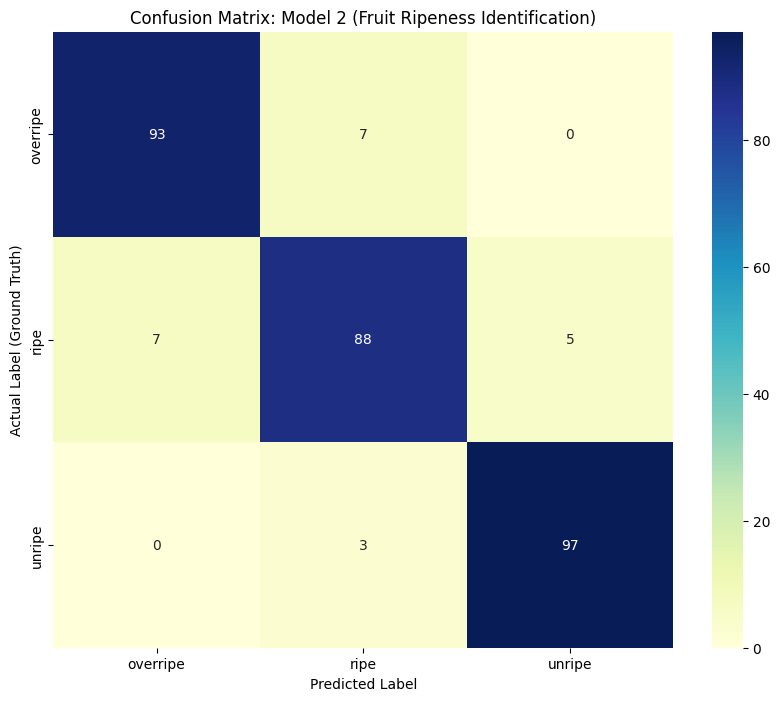


HASIL EVALUASI PERFORMA MODEL 2 (RIPENESS)
              precision    recall  f1-score   support

    overripe     0.9300    0.9300    0.9300       100
        ripe     0.8980    0.8800    0.8889       100
      unripe     0.9510    0.9700    0.9604       100

    accuracy                         0.9267       300
   macro avg     0.9263    0.9267    0.9264       300
weighted avg     0.9263    0.9267    0.9264       300

Total Accuracy (Global): 92.67%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. KONFIGURASI TEST GENERATOR (DETERMINISTIK) ---
# Menggunakan folder 'test' dari dataset kematangan
TEST_DIR = 'master_dataset/dataset_kematangan_buah/test'
print("[INFO] Mengonfigurasi test generator untuk evaluasi...")

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- 2. PROSES INFERENSI ---
print("[INFO] Melakukan prediksi pada dataset test kematangan...")
test_generator.reset()
Y_pred = model_ripeness.predict(test_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# --- 3. GENERATE CONFUSION MATRIX ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.title('Confusion Matrix: Model 2 (Fruit Ripeness Identification)')
plt.ylabel('Actual Label (Ground Truth)')
plt.xlabel('Predicted Label')
plt.show()

# --- 4. CALCULATE STATISTICAL METRICS (Standard Scientific Paper) ---
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)

print("\n" + "="*60)
print("HASIL EVALUASI PERFORMA MODEL 2 (RIPENESS)")
print("="*60)
print(report)

overall_accuracy = accuracy_score(y_true, y_pred)
print(f"Total Accuracy (Global): {overall_accuracy * 100:.2f}%")
print("="*60)

FINE TUNED ARE

In [ ]:
# --- cell 7: fine-tuning ---
import tensorflow as tf
import os
import json
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("[info] menginisialisasi ulang dependencies...")

# 1. pastikan generator didefinisikan ulang
base_dir = 'master_dataset/dataset_kematangan_buah'
val_test_datagen = ImageDataGenerator(rescale=1./255)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# 2. muat ulang model & base_model
if 'model_ripeness' not in locals():
    model_ripeness = tf.keras.models.load_model('models/model_ripeness_best.h5')

base_model = model_ripeness.layers[0]

# 3. konfigurasi fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model_ripeness.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. eksekusi fine-tuning
print("[info] memulai training fine-tuning...")
checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    'models/model_ripeness_finetuned.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    verbose=1
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

history_ft = model_ripeness.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weight_dict if 'class_weight_dict' in locals() else None, 
    callbacks=[checkpoint_ft, lr_scheduler],
    verbose=1
)

[info] menginisialisasi ulang dependencies...
Found 2341 images belonging to 3 classes.
Found 300 images belonging to 3 classes.
[info] memulai training fine-tuning...
Epoch 1/10


2026-05-03 21:15:34.654517: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.8184 - loss: 0.4928
Epoch 1: val_accuracy improved from None to 0.91667, saving model to models/model_ripeness_finetuned.h5



Epoch 1: finished saving model to models/model_ripeness_finetuned.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 274ms/step - accuracy: 0.8321 - loss: 0.4736 - val_accuracy: 0.9167 - val_loss: 0.2314 - learning_rate: 1.0000e-05
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.8598 - loss: 0.3797
Epoch 2: val_accuracy did not improve from 0.91667
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 205ms/step - accuracy: 0.8603 - loss: 0.3875 - val_accuracy: 0.9033 - val_loss: 0.2586 - learning_rate: 1.0000e-05
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.8652 - loss: 0.3669
Epoch 3: val_accuracy did not improve from 0.91667
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 227ms/step - accuracy: 0.8706 - loss: 0.3503 - val_accuracy: 0.9000 - val_loss: 0.2717 - learning_rate: 1.0000e-05
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.8716 - loss: 0.3273
Epoch 4: val_accuracy did not improve from 0.91667
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 233ms/step - accuracy: 0.8765 - loss: 0.3234 - val


Epoch 9: finished saving model to models/model_ripeness_finetuned.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 214ms/step - accuracy: 0.8864 - loss: 0.3077 - val_accuracy: 0.9200 - val_loss: 0.2265 - learning_rate: 4.0000e-07
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.8682 - loss: 0.3137
Epoch 10: val_accuracy improved from 0.92000 to 0.92333, saving model to models/model_ripeness_finetuned.h5



Epoch 10: finished saving model to models/model_ripeness_finetuned.h5
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 241ms/step - accuracy: 0.8774 - loss: 0.2977 - val_accuracy: 0.9233 - val_loss: 0.2192 - learning_rate: 4.0000e-07


[info] mengonfigurasi ulang test generator...
Found 300 images belonging to 3 classes.
[info] melakukan prediksi pada dataset test ripeness...
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 340ms/step


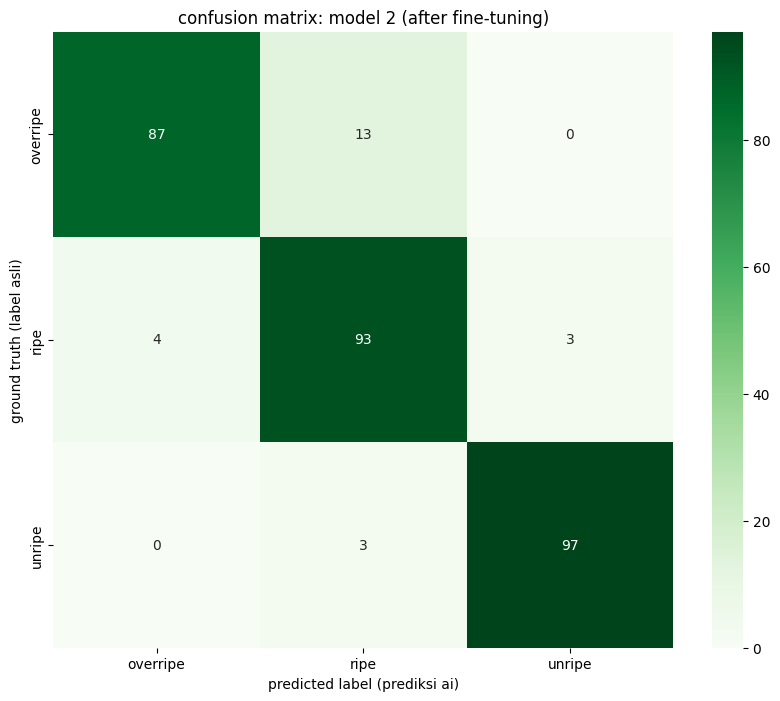


hasil evaluasi final model 2 - ripeness (after fine-tuning)
              precision    recall  f1-score   support

    overripe     0.9560    0.8700    0.9110       100
        ripe     0.8532    0.9300    0.8900       100
      unripe     0.9700    0.9700    0.9700       100

    accuracy                         0.9233       300
   macro avg     0.9264    0.9233    0.9236       300
weighted avg     0.9264    0.9233    0.9236       300

total accuracy final: 92.33%


In [ ]:
# --- cell 8: evaluasi akhir model 2 ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# 1. re-definisi test_generator agar tidak nameerror
print("[info] mengonfigurasi ulang test generator...")
base_dir = 'master_dataset/dataset_kematangan_buah'
val_test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 2. pastiin test generator dalam kondisi bersih
test_generator.reset()

# 3. inferensi pake model yang barusan di-fine-tune di memori ram
print("[info] melakukan prediksi pada dataset test ripeness...")
y_pred_probs = model_ripeness.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# 4. visualisasi confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels, 
            yticklabels=class_labels)
plt.title('confusion matrix: model 2 (after fine-tuning)')
plt.ylabel('ground truth (label asli)')
plt.xlabel('predicted label (prediksi ai)')
plt.show()

# 5. print classification report
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
print("\n" + "="*60)
print("hasil evaluasi final model 2 - ripeness (after fine-tuning)")
print("="*60)
print(report)

final_acc = accuracy_score(y_true, y_pred)
print(f"total accuracy final: {final_acc * 100:.2f}%")
print("="*60)

In [ ]:
# --- CELL 9: SAVE UPDATED JSON ---
import json

# Mengambil indeks dari generator terbaru
class_indices_final = train_generator.class_indices

with open('models/class_indices_ripeness.json', 'w') as f:
    json.dump(class_indices_final, f)

print(f"[SUCCESS] Kamus label final disimpan: {class_indices_final}")

[SUCCESS] Kamus label final disimpan: {'overripe': 0, 'ripe': 1, 'unripe': 2}


In [ ]:
# --- CELL 11: BENCHMARKING LATENCY (M2 PERFORMANCE) ---
import time
import numpy as np

def benchmark_ripeness(num_trials=50):
    # 1. Ambil satu sampel gambar dari generator untuk simulasi inferensi
    test_generator.reset()
    images, _ = next(test_generator)
    single_img = np.expand_dims(images[0], axis=0)
    
    print(f"[INFO] Memulai benchmark Model 2 (Fine-Tuned) pada {num_trials} percobaan...")
    
    # 2. Proses Warm-up
    _ = model_ripeness.predict(single_img, verbose=0)
    
    # 3. Hitung waktu total inferensi
    start_time = time.time()
    for _ in range(num_trials):
        # Menggunakan model_ripeness yang merupakan hasil fine-tuning
        _ = model_ripeness.predict(single_img, verbose=0)
    end_time = time.time()
    
    # 4. Kalkulasi Rata-rata
    avg_time = (end_time - start_time) / num_trials
    fps = 1 / avg_time
    
    print("\n" + "="*45)
    print("HASIL BENCHMARK LATENSI MODEL 2 (APPLE M2)")
    print("="*45)
    print(f"Rata-rata Waktu Inferensi : {avg_time * 1000:.2f} ms")
    print(f"Estimasi Throughput       : {fps:.2f} FPS")
    print("="*45)
    print("[INFO] Data ini sangat berguna untuk Bab 4 paper kamu.")

# Jalankan benchmark
benchmark_ripeness()

[INFO] Memulai benchmark Model 2 (Fine-Tuned) pada 50 percobaan...

HASIL BENCHMARK LATENSI MODEL 2 (APPLE M2)
Rata-rata Waktu Inferensi : 45.75 ms
Estimasi Throughput       : 21.86 FPS
[INFO] Data ini sangat berguna untuk Bab 4 paper kamu.
